In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
sns.set()

In [2]:
p = np.array([1, 1])
q = np.array([1, -1])

In [3]:
w0 = np.array([1 + np.log(2), 1 - np.log(2)])

beta = 0.9
a = (1-beta) / (1+beta)
c = a / 2
print(2 * c)

max_iter = 5000 #int(1e4)

0.05263157894736841


# Sign subgradient descent with momentum

**Algorithm**

| Step | Operation |
|------|-----------|
| Init | $M_0 = 0$|
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $M_t = \beta M_t + (1-\beta) G_t$ |
| 3 | $W_{t+1} = W_t - \alpha_t\mathrm{LMO}_{\|\cdot\|}(M_t)$ | 

In [4]:
w, logging = sign_subgradient_descent_momentum(w0=w0, c=c, p=p, q=q, s=0, max_iters=max_iter, beta=beta)
ws = np.array(logging["w"])

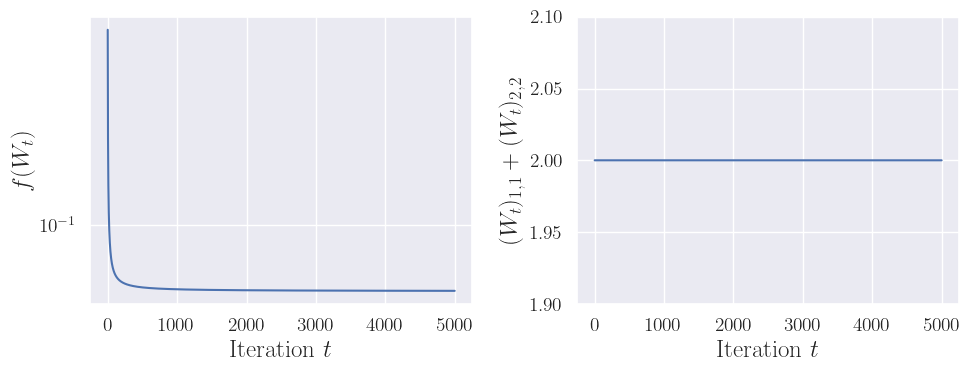

In [5]:
experiment_name = "countex_sign_subgrad_momentum"
plot_loss_and_w_sum(ws, logging, filename=f"{experiment_name}_loss_and_w_sum", 
                    max_iter=max_iter)

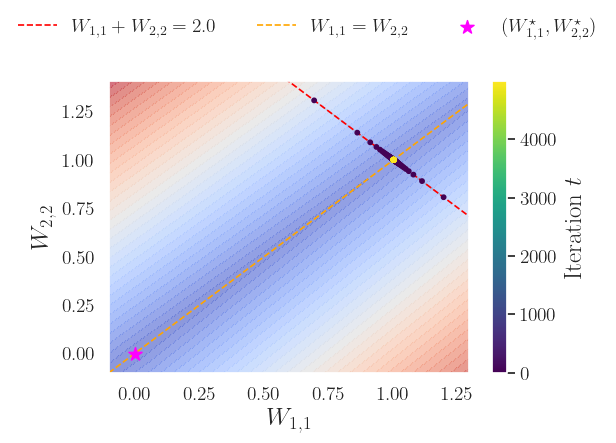

In [6]:
plot_trajectory(ws, w0, c, n_show=max_iter, filename=experiment_name)

# Sign subgradient descent with EF

**Algorithm**

| Step | Operation |
|------|-----------|
| Init | $E_0 = 0$, $\gamma = 1/\sqrt{T}$ |
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $M_t = \gamma G_t + E_t$ |
| 3 | $W_{t+1} = W_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(M_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(M_t)$ |
| 4 | $E_{t+1} = M_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(M_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(M_t)$ |

In [7]:
w, logging = sign_subgradient_descent_ef(w0=w0, c=c, p=p, q=q, s=0, max_iters=max_iter, gamma0=1e-2, fixed_gamma=True)
ws = np.array(logging["w"])

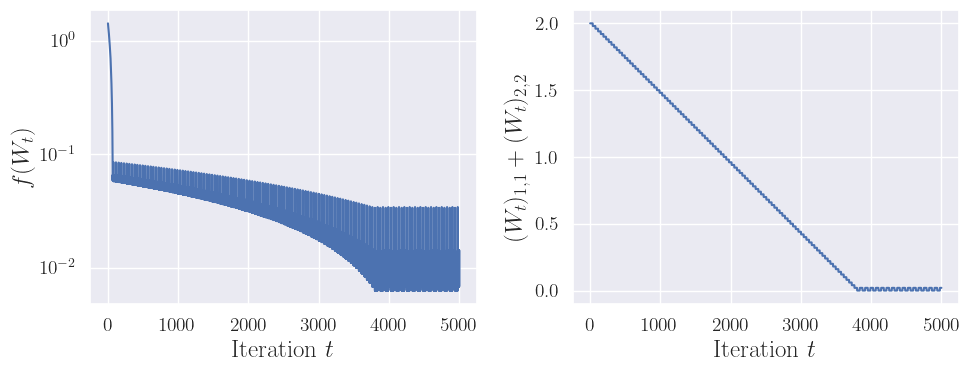

In [8]:
experiment_name = "countex_sign_subgrad_ef"
plot_loss_and_w_sum(ws, logging, filename=f"{experiment_name}_loss_and_w_sum", xlog=False, max_iter=max_iter)

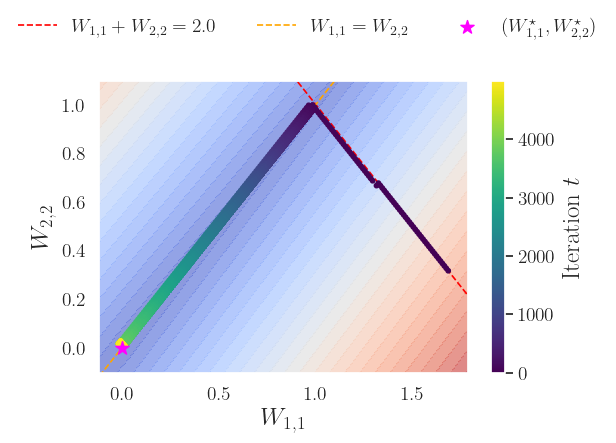

In [9]:
plot_trajectory(ws, w0, c, n_show=max_iter, filename=experiment_name)

# Sign subgradient descent with EF

**Algorithm**

| Step | Operation |
|------|-----------|
| Init | $E_0 = 0$ |
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $P_t = (1 / \sqrt{t+1}) G_t + E_t$ |
| 3 | $W_{t+1} = W_t - \dfrac{\|P_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |
| 4 | $E_{t+1} = P_t - \dfrac{\|P_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |

In [10]:
w, logging = sign_subgradient_descent_ef(w0=w0, c=c, p=p, q=q, s=0, max_iters=max_iter, 
                                         fixed_gamma=False)
ws = np.array(logging["w"])

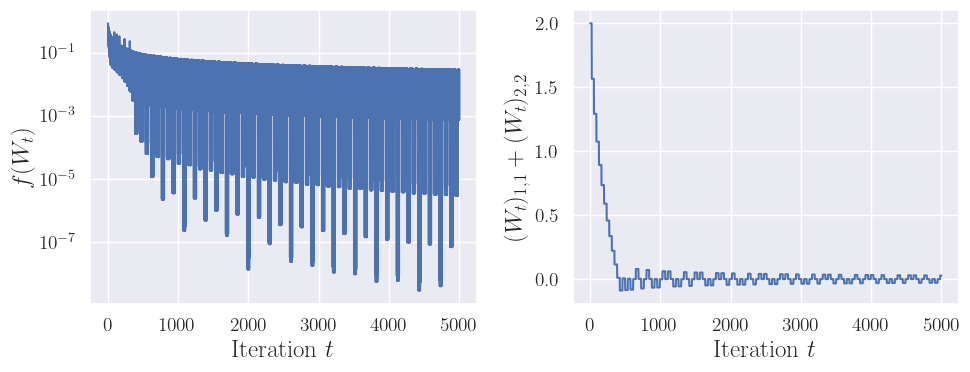

In [11]:
experiment_name = "countex_sign_subgrad_ef_gamma_t"
plot_loss_and_w_sum(ws, logging, filename=f"{experiment_name}_loss_and_w_sum", 
                    xlog=False, max_iter=max_iter)

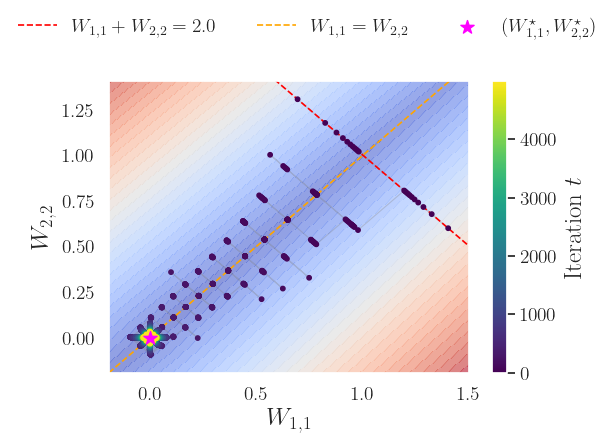

In [12]:
plot_trajectory(ws, w0, c, n_show=max_iter, filename=experiment_name)

# Sign subgradient descent with EF and Momentum

**Algorithm**

| Step | Operation |
|------|-----------|
| Init | $E_0=M_0 = 0$ |
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $M_t = \beta M_{t-1} + (1 - \beta) G_t$ |
| 3 | $P_t = \frac{1}{\sqrt{t+1}} M_t + E_t$ |
| 4 | $W_{t+1} = W_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |
| 5 | $E_{t+1} = M_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |

In [13]:
w, logging = sign_subgradient_descent_ef_momentum(w0=w0, c=c, p=p, q=q, beta=beta, s=0, max_iters=max_iter, 
                                                  fixed_gamma=False)
ws = np.array(logging["w"])

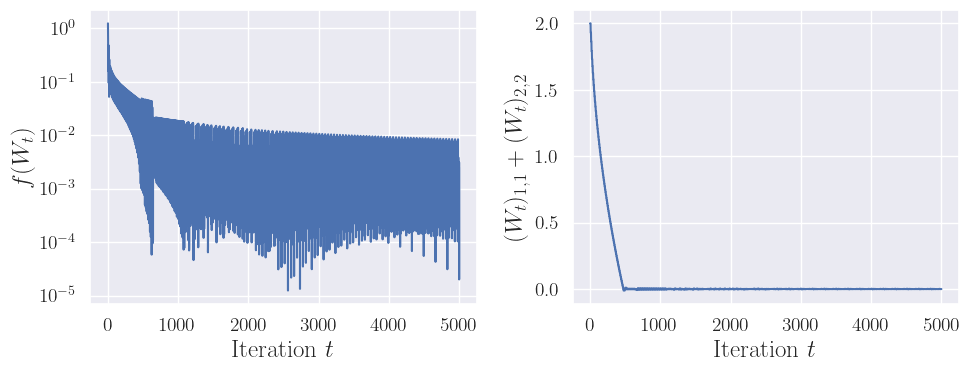

In [14]:
experiment_name = "countex_sign_subgrad_ef_m_gamma_t"
plot_loss_and_w_sum(ws, logging, filename=f"{experiment_name}_loss_and_w_sum", 
                    xlog=False, max_iter=max_iter)

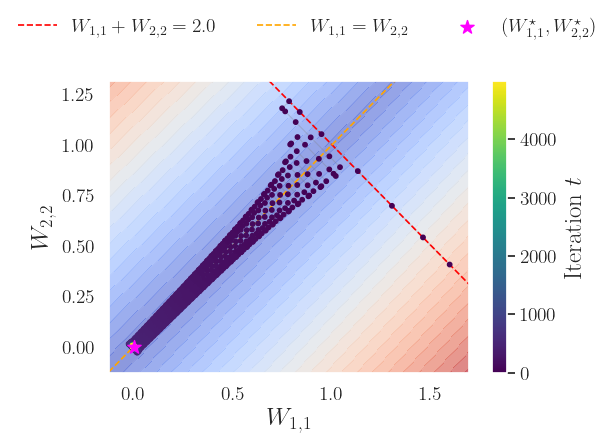

In [15]:
plot_trajectory(ws, w0, c, n_show=max_iter, filename=experiment_name)

# Sign subgradient descent with EF and Momentum

**Algorithm**

| Step | Operation |
|------|-----------|
| Init | $E_0=M_0 = 0$ |
| **for** $t = 0, 1, \dots, T-1$ | |
| 1 | $G_t \in \partial f(W_t)$ |
| 2 | $M_t = \beta M_{t-1} + (1 - \beta) G_t$ |
| 3 | $P_t = \frac{1}{\sqrt{T+1}} M_t + E_t$ |
| 4 | $W_{t+1} = W_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |
| 5 | $E_{t+1} = M_t - \dfrac{\|M_t\|_{\mathrm{nuc}}}{\mathrm{rank}(P_t)} \cdot \mathrm{LMO}_{\|\cdot\|}(P_t)$ |

In [16]:
max_iter = 50000

In [17]:
w, logging = sign_subgradient_descent_ef_momentum(w0=w0, c=c, p=p, q=q, beta=beta, s=0, max_iters=max_iter, 
                                                  fixed_gamma=True, gamma0=1e-3)
ws = np.array(logging["w"])

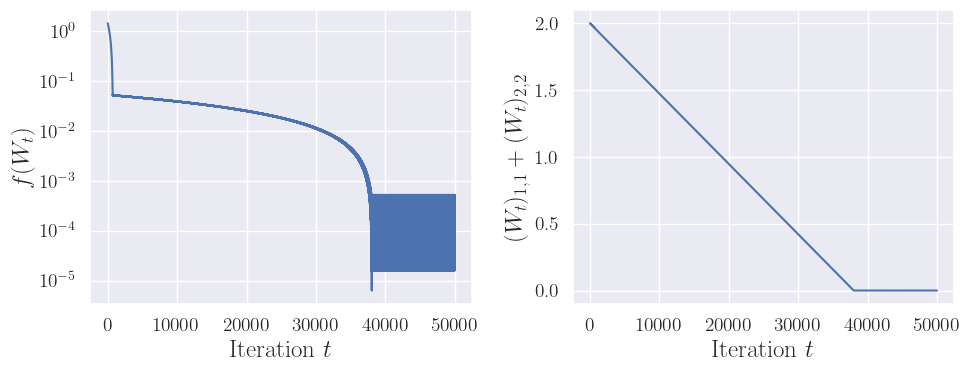

In [18]:
experiment_name = "countex_sign_subgrad_ef_m_gamma"
plot_loss_and_w_sum(ws, logging, filename=f"{experiment_name}_loss_and_w_sum", 
                    xlog=False, max_iter=max_iter)

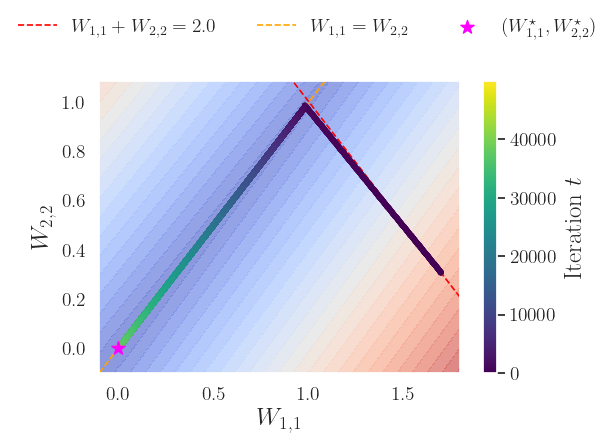

In [19]:
plot_trajectory(ws, w0, c, n_show=max_iter, filename=experiment_name)

In [20]:
c, w0

(0.026315789473684206, array([1.69314718, 0.30685282]))